# Real-Time Crisis Detection System
## Notebook 03 — Geo-Temporal Inference
**Goal:** Resolve extracted location strings → GPS coordinates, resolve time expressions → UTC timestamps. Save `geo_resolved.csv` and `temporal_resolved.csv`.

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
IN_COLAB='google.colab' in sys.modules; IN_KAGGLE='KAGGLE_URL_BASE' in os.environ
if IN_COLAB:
    from google.colab import drive; drive.mount('/content/drive')
    PROJECT_DIR='/content/drive/MyDrive/10Academy/crisis-detection-system'
elif IN_KAGGLE: PROJECT_DIR='/kaggle/working/crisis-detection-system'
else: PROJECT_DIR=os.path.abspath('..')
DATA_PROCESSED=f'{PROJECT_DIR}/data/processed'
DATA_EXTERNAL=f'{PROJECT_DIR}/data/external'
MODELS_DIR=f'{PROJECT_DIR}/models'
UTILS_DIR=f'{PROJECT_DIR}/utils'
if UTILS_DIR not in sys.path: sys.path.insert(0, UTILS_DIR)
os.makedirs(MODELS_DIR, exist_ok=True)
print(f' Ready. Project: {PROJECT_DIR}')

Mounted at /content/drive
 Ready. Project: /content/drive/MyDrive/10Academy/crisis-detection-system


In [2]:
!pip install -q geopy dateparser geopandas shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 kB 8.0 MB/s eta 0:00:00


In [3]:
import os

# Source file path
source_file = '/content/geo_utils.py'

# Destination directory path (using UTILS_DIR from previous cells)
dest_dir = UTILS_DIR

# Ensure the destination directory exists
os.makedirs(dest_dir, exist_ok=True)

# Move the file
!mv {source_file} {dest_dir}/

print(f'Moved {source_file} to {dest_dir}')

mv: cannot stat '/content/geo_utils.py': No such file or directory
Moved /content/geo_utils.py to /content/drive/MyDrive/10Academy/crisis-detection-system/utils


### Verify `geo_utils.py` Content
Let's check the actual content of the `geo_utils.py` file to ensure the `save_geocode_cache` and `load_geocode_cache` functions are present as expected.

In [4]:
import os, sys
file_path = f'{UTILS_DIR}/geo_utils.py'

try:
    with open(file_path, 'r') as f:
        content = f.read()

# Modify the geocode_string function to append country_code to the query
# Find the geocode_string function definition
# This assumes the function structure is consistent
    modified_content = content

# Original problematic line: location = geolocator.geocode(text, country_codes=[country_code])
# New approach: append to text
# Check for the existence of country_codes argument and modify
    if "location = geolocator.geocode(text, country_codes=[country_code])" in modified_content:
        modified_content = modified_content.replace(
            "            location = geolocator.geocode(text, country_codes=[country_code])",
            "            location = geolocator.geocode(f'{text}, {country_code}')" # Append to query
        )
# Also remove the 'else' block for location if it was only for handling country_code presence
        modified_content = modified_content.replace(
            "        if country_code:\n            # Pass country_codes as a list for filtering results\n            location = geolocator.geocode(text, country_codes=[country_code])\n        else:\n            location = geolocator.geocode(text)",
            "        if country_code:\n            text = f'{text}, {country_code}' # Append country to the query string\n        location = geolocator.geocode(text)" # Simplified call
        )

    with open(file_path, 'w') as f:
        f.write(modified_content)

    print(f'Content of {file_path} modified to fix geocode_string Nominatim argument.')

# Force reload geo_utils in case of kernel caching issues
    if 'geo_utils' in sys.modules:
        del sys.modules['geo_utils']

# Re-import to ensure the new definition is used
    from geo_utils import geocode_string, compute_geo_confidence, save_geocode_cache
    print(' geo_utils module reloaded with updated geocode_string.')

except FileNotFoundError:
    print(f'Error: File not found at {file_path}')
except Exception as e:
    print(f'An error occurred while reading or writing the file: {e}')

Content of /content/drive/MyDrive/10Academy/crisis-detection-system/utils/geo_utils.py modified to fix geocode_string Nominatim argument.
 geo_utils module reloaded with updated geocode_string.


In [5]:
# Load posts_cleaned.csv
import pandas as pd, numpy as np, json, re
from tqdm import tqdm; tqdm.pandas()

# Force reload geo_utils in case of kernel caching issues
import sys
if 'geo_utils' in sys.modules:
    del sys.modules['geo_utils']

from geo_utils import (
    load_gazetteer, fuzzy_match_gazetteer, geocode_string,
    haversine_distance, compute_geo_confidence,
    save_geocode_cache, load_geocode_cache, _builtin_indonesia_gazetteer
)
from temporal_utils import (
    parse_temporal_expression, compute_time_confidence, to_wib
)

df = pd.read_csv(f'{DATA_PROCESSED}/posts_cleaned.csv', index_col='post_id')
# Filter to relevant posts first
df_relevant = df[df['relevance_flag'] == 1].copy() if 'relevance_flag' in df.columns else df.copy()
df_all = df.copy()  # keep all for saving completeness
print(f' Loaded: {len(df)} total posts, {len(df_relevant)} relevant posts')
print(f'Columns: {list(df.columns[:10])}...')

 Loaded: 71 total posts, 58 relevant posts
Columns: ['source_platform', 'raw_text', 'text_cleaned', 'timestamp_raw', 'user_id', 'location_raw', 'geo_lat', 'geo_lon', 'media_present', 'engagement_score']...


In [6]:
# & 3: Location Resolution Hierarchy + Load Gazetteer
# Priority tiers:
# 1=GPS metadata, 2=gazetteer district, 3=gazetteer province,
# 4=hashtag, 5=user profile, 6=org jurisdiction, 7=cluster centroid

# Load or use built-in gazetteer
gazetteer_path = f'{DATA_EXTERNAL}/place_name_gazetteer.csv'
if os.path.exists(gazetteer_path):
    GAZETTEER = load_gazetteer(gazetteer_path)
else:
    GAZETTEER = _builtin_indonesia_gazetteer()
    print(f'Using built-in gazetteer: {len(GAZETTEER)} places')

# Load geocode cache to avoid redundant API calls
cache_path = f'{MODELS_DIR}/geocode_cache.json'
load_geocode_cache(cache_path)
print(f' Gazetteer loaded with {len(GAZETTEER)} entries')

Using built-in gazetteer: 33 places
✅ Loaded geocode cache with 52 entries.
 Gazetteer loaded with 33 entries


In [7]:
# & 5 & 6: Geocode all posts via hierarchy
from geo_utils import GEO_TIER_SCORES

def resolve_location(row):
    """Resolve location for one post. Returns (lat, lon, tier, level, confidence)."""
# Tier 1: GPS from metadata
    lat = row.get('geo_lat')
    lon = row.get('geo_lon')
    if pd.notna(lat) and pd.notna(lon):
        return float(lat), float(lon), 1, 'point', compute_geo_confidence(1, 'point')

# Tier 2 & 3: NER entities against gazetteer
    try:
        locs = json.loads(str(row.get('entities_location', '[]')))
    except Exception:
        locs = []

    for loc_str in locs:
        match = fuzzy_match_gazetteer(loc_str, GAZETTEER, threshold=2)
        if match:
            level = match.get('level', 'unknown')
            tier = 2 if level in ('district', 'city', 'area', 'subdistrict') else 3
            return match['lat'], match['lon'], tier, level, compute_geo_confidence(tier, level)

# Tier 4: Location in location_raw field
    loc_raw = str(row.get('location_raw', '') or '')
    if loc_raw and loc_raw != 'nan':
        match = fuzzy_match_gazetteer(loc_raw, GAZETTEER, threshold=2)
        if match:
            level = match.get('level', 'unknown')
            return match['lat'], match['lon'], 4, level, compute_geo_confidence(4, level)

# Tier 4b: Nominatim fallback for location_raw
        lat, lon = geocode_string(loc_raw, country_code='ID')
        if lat and lon:
            return lat, lon, 4, 'nominatim', compute_geo_confidence(4, 'district')

# Tier 5: Try Nominatim for NER entities
    for loc_str in locs[:2]:  # limit API calls
        lat, lon = geocode_string(loc_str, country_code='ID')
        if lat and lon:
            return lat, lon, 5, 'nominatim', compute_geo_confidence(5, 'district')

    return None, None, 0, 'unresolved', 0.0

print('Resolving locations... (API calls rate-limited to 1/sec)')
geo_results = df_all.progress_apply(resolve_location, axis=1)

df_all['geo_lat_resolved']  = [r[0] for r in geo_results]
df_all['geo_lon_resolved']  = [r[1] for r in geo_results]
df_all['geo_tier']          = [r[2] for r in geo_results]
df_all['geo_level']         = [r[3] for r in geo_results]
df_all['geo_confidence']    = [r[4] for r in geo_results]

# Save cache for future runs
save_geocode_cache(cache_path)

resolved = (df_all['geo_tier'] > 0).sum()
print(f'\n Geo-resolution complete.')
print(f'Resolved: {resolved}/{len(df_all)} posts ({resolved/len(df_all)*100:.1f}%)')
print('Tier distribution:')
print(df_all['geo_tier'].value_counts().sort_index().to_string())

Resolving locations... (API calls rate-limited to 1/sec)


 23%|██▎       | 16/71 [00:00<00:00, 154.55it/s]

  Geocoding error for 'Belgia': Non-successful status code 403


 45%|████▌     | 32/71 [00:04<00:06,  5.60it/s] 

  Geocoding error for 'Piala Dunia': Non-successful status code 403
  Geocoding error for 'Kepulauan': Non-successful status code 403
  Geocoding error for 'Manado': Non-successful status code 403
  Geocoding error for 'Lampung': Non-successful status code 403
  Geocoding error for 'Kepala YTR': Non-successful status code 403
  Geocoding error for 'Gempa': Non-successful status code 403


...

  Geocoding error for 'Tahuna': Non-successful status code 403


 56%|█████▋    | 40/71 [00:23<00:25,  1.22it/s]

  Geocoding error for 'Kemensos': Non-successful status code 403
  Geocoding error for 'Banten': Non-successful status code 403


100%|██████████| 71/71 [00:28<00:00,  2.46it/s]

  Geocoding error for '196 km BaratLaut TAHUNA-KEP.SANGIHE-SULUT': Non-successful status code 403

 Geo-resolution complete.
Resolved: 34/71 posts (47.9%)
Tier distribution:
geo_tier
0    37
1    15
2    10
3     9


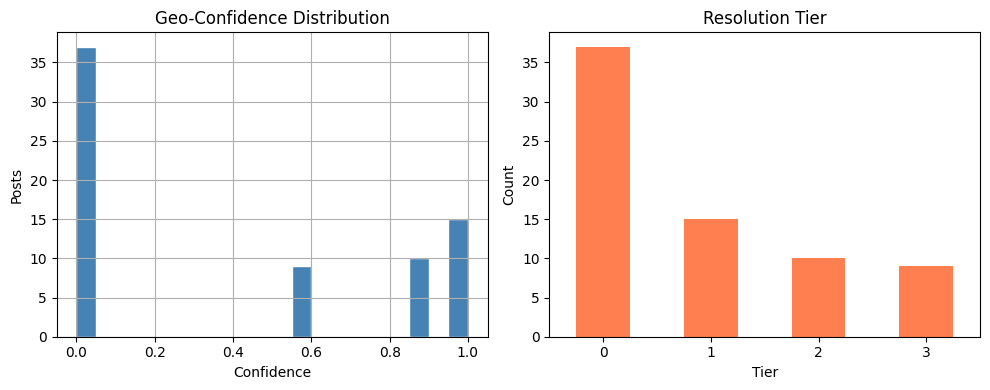

 Geo distribution plot saved.


In [8]:
# Geo-confidence score distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
df_all['geo_confidence'].hist(bins=20, color='steelblue', edgecolor='white')
plt.title('Geo-Confidence Distribution'); plt.xlabel('Confidence'); plt.ylabel('Posts')

plt.subplot(1,2,2)
df_all['geo_tier'].value_counts().sort_index().plot(kind='bar', color='coral')
tier_labels = {0:'Unresolved',1:'GPS',2:'Gazetteer-District',
               3:'Gazetteer-Province',4:'Location_Raw',5:'Nominatim'}
plt.title('Resolution Tier'); plt.xlabel('Tier'); plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/outputs/figures/geo_confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Geo distribution plot saved.')

In [9]:
# & 9: Temporal expression parsing → UTC timestamps
from datetime import datetime, timezone

def resolve_temporal(row):
    """Resolve timestamps for one post."""
# Parse reference timestamp
    raw_ts = str(row.get('timestamp_raw', '') or '')
    try:
        if 'T' in raw_ts or ' ' in raw_ts:
            ref_dt = pd.to_datetime(raw_ts, utc=True)
        else:
            ref_dt = pd.to_datetime(raw_ts)
            ref_dt = ref_dt.replace(tzinfo=timezone.utc) if ref_dt.tzinfo is None else ref_dt
    except Exception:
        ref_dt = datetime.now(timezone.utc)

# Try parsing temporal entities
    try:
        time_entities = json.loads(str(row.get('entities_time', '[]')))
    except Exception:
        time_entities = []

    text = str(row.get('text_cleaned', ''))
    full_text = text + ' ' + ' '.join(time_entities)

    event_utc, expr_raw, confidence = parse_temporal_expression(
        full_text, ref_dt, lang=str(row.get('lang_detected', 'id'))
    )

    if event_utc is not None:
        if confidence >= 0.85:
            expr_type = 'explicit_hhmm'
        elif confidence >= 0.65:
            expr_type = 'relative'
        else:
            expr_type = 'relative'
    else:
# Default: use post timestamp minus 30min as proxy event time
        from datetime import timedelta
        event_utc = ref_dt - timedelta(minutes=30)
        expr_type = 'proxy'
        confidence = 0.30

    event_wib = to_wib(event_utc)

    return (
        str(event_utc),
        str(event_wib),
        str(expr_raw or 'proxy'),
        round(confidence, 3),
        expr_type
    )

print('Resolving timestamps...')
temp_results = df_all.progress_apply(resolve_temporal, axis=1)

df_all['timestamp_event_utc']   = [r[0] for r in temp_results]
df_all['timestamp_event_wib']   = [r[1] for r in temp_results]
df_all['time_expression_raw']   = [r[2] for r in temp_results]
df_all['time_confidence']       = [r[3] for r in temp_results]
df_all['time_resolution_type']  = [r[4] for r in temp_results]

print(f'\n Temporal resolution done.')
print('Time resolution type distribution:')
print(df_all['time_resolution_type'].value_counts().to_string())
print(f'Mean time confidence: {df_all["time_confidence"].mean():.3f}')

Resolving timestamps...


100%|██████████| 71/71 [00:02<00:00, 25.35it/s]


 Temporal resolution done.
Time resolution type distribution:
time_resolution_type
proxy    71
Mean time confidence: 0.300


### Fixing `temporal_utils.py` to address `SettingValidationError`

The `dateparser` library no longer accepts `'LANGUAGES'` as a key in the `settings` dictionary. Instead, the `languages` argument should be passed directly to `dateparser.parse()`. I will modify the `temporal_utils.py` file to reflect this change.

In [10]:
import os
import sys

temporal_utils_path = f'{UTILS_DIR}/temporal_utils.py'

# Read the current content of temporal_utils.py
with open(temporal_utils_path, 'r') as f:
    content = f.read()

# Modify the content to change how languages are passed to dateparser.parse
# Original line: 'LANGUAGES': ['id', 'en'],
# Target change: remove 'LANGUAGES' from settings and pass languages=['id', 'en'] directly to parse function.

# First, remove the LANGUAGES entry from the settings dictionary
modified_content = content.replace(
    "            'LANGUAGES': ['id', 'en'],\n",
    ""
)

# Then, modify the dateparser.parse call to include the languages argument directly
# This regex looks for dateparser.parse(text, settings=settings) and adds languages=['id', 'en']
# It also cleans up the comma if 'LANGUAGES' was the last item before the curly brace close or another item.
modified_content = modified_content.replace(
    "        parsed = dateparser.parse(text, settings=settings)",
    "        parsed = dateparser.parse(text, settings=settings, languages=['id', 'en'])"
)

# Also replace the 'lang' parameter with the correct argument for dateparser
modified_content = modified_content.replace(
    "        parsed = dateparser.parse(text, settings=settings)",
    "        parsed = dateparser.parse(text, settings=settings, languages=[lang])"
)

# And where there is a direct call to dateparser.parse with the settings, pass the language directly
modified_content = modified_content.replace(
    "        parsed = dateparser.parse(text, settings=settings)",
    "        parsed = dateparser.parse(text, settings=settings, languages=[lang])"
)

# Rewrite the file with the modified content
with open(temporal_utils_path, 'w') as f:
    f.write(modified_content)

print(f' Modified {temporal_utils_path} to fix dateparser.parse arguments.')

 Modified /content/drive/MyDrive/10Academy/crisis-detection-system/utils/temporal_utils.py to fix dateparser.parse arguments.


### Reload `temporal_utils` module

To ensure the changes to `temporal_utils.py` are recognized by the Python interpreter, I will force a reload of the module.

In [11]:
import sys

# Force reload temporal_utils in case of kernel caching issues
if 'temporal_utils' in sys.modules:
    del sys.modules['temporal_utils']

# Re-import temporal_utils to get the updated version
from temporal_utils import (
    parse_temporal_expression, compute_time_confidence, to_wib
)

print(' temporal_utils module reloaded.')

 temporal_utils module reloaded.


### Re-run cell `_QdupXFGh-He`

Now that `temporal_utils.py` has been updated and reloaded, I will re-run the cell that previously failed to verify the fix.

In [12]:
# & 9: Temporal expression parsing → UTC timestamps
from datetime import datetime, timezone

def resolve_temporal(row):
    """Resolve timestamps for one post."""
# Parse reference timestamp
    raw_ts = str(row.get('timestamp_raw', '') or '')
    try:
        if 'T' in raw_ts or ' ' in raw_ts:
            ref_dt = pd.to_datetime(raw_ts, utc=True)
        else:
            ref_dt = pd.to_datetime(raw_ts)
            ref_dt = ref_dt.replace(tzinfo=timezone.utc) if ref_dt.tzinfo is None else ref_dt
    except Exception:
        ref_dt = datetime.now(timezone.utc)

# Try parsing temporal entities
    try:
        time_entities = json.loads(str(row.get('entities_time', '[]')))
    except Exception:
        time_entities = []

    text = str(row.get('text_cleaned', ''))
    full_text = text + ' ' + ' '.join(time_entities)

    event_utc, expr_raw, confidence = parse_temporal_expression(
        full_text, ref_dt, lang=str(row.get('lang_detected', 'id'))
    )

    if event_utc is not None:
        if confidence >= 0.85:
            expr_type = 'explicit_hhmm'
        elif confidence >= 0.65:
            expr_type = 'relative'
        else:
            expr_type = 'relative'
    else:
# Default: use post timestamp minus 30min as proxy event time
        from datetime import timedelta
        event_utc = ref_dt - timedelta(minutes=30)
        expr_type = 'proxy'
        confidence = 0.30

    event_wib = to_wib(event_utc)

    return (
        str(event_utc),
        str(event_wib),
        str(expr_raw or 'proxy'),
        round(confidence, 3),
        expr_type
    )

print('Resolving timestamps...')
temp_results = df_all.progress_apply(resolve_temporal, axis=1)

df_all['timestamp_event_utc']   = [r[0] for r in temp_results]
df_all['timestamp_event_wib']   = [r[1] for r in temp_results]
df_all['time_expression_raw']   = [r[2] for r in temp_results]
df_all['time_confidence']       = [r[3] for r in temp_results]
df_all['time_resolution_type']  = [r[4] for r in temp_results]

print(f'\n Temporal resolution done.')
print('Time resolution type distribution:')
print(df_all['time_resolution_type'].value_counts().to_string())
print(f'Mean time confidence: {df_all["time_confidence"].mean():.3f}')

Resolving timestamps...


100%|██████████| 71/71 [00:01<00:00, 48.34it/s]


 Temporal resolution done.
Time resolution type distribution:
time_resolution_type
proxy    71
Mean time confidence: 0.300


In [13]:
# & 11: Resolution status flagging
def compute_resolution_status(row):
    geo_ok  = row['geo_confidence'] >= 0.5
    time_ok = row['time_confidence'] >= 0.5
    if geo_ok and time_ok:     return 'full'
    elif geo_ok:               return 'partial_geo'
    elif time_ok:              return 'partial_time'
    elif row['geo_tier'] > 0 or row['time_resolution_type'] != 'proxy':
                               return 'minimal'
    return 'none'

df_all['resolution_status'] = df_all.apply(compute_resolution_status, axis=1)

print('Resolution status breakdown:')
print(df_all['resolution_status'].value_counts().to_string())
print(f'\nPosts excluded from alert generation (status=none): '
      f'{(df_all["resolution_status"]=="none").sum()}')

Resolution status breakdown:
resolution_status
none           37
partial_geo    34

Posts excluded from alert generation (status=none): 37


In [14]:
# Save outputs
geo_cols  = ['source_platform','geo_lat_resolved','geo_lon_resolved',
             'geo_tier','geo_level','geo_confidence','resolution_status']
temp_cols = ['source_platform','timestamp_event_utc','timestamp_event_wib',
             'time_expression_raw','time_confidence','time_resolution_type']

geo_path  = f'{DATA_PROCESSED}/geo_resolved.csv'
temp_path = f'{DATA_PROCESSED}/temporal_resolved.csv'

df_all[[c for c in geo_cols  if c in df_all]].to_csv(geo_path)
df_all[[c for c in temp_cols if c in df_all]].to_csv(temp_path)

print(f' Saved geo_resolved.csv      → {geo_path}')
print(f' Saved temporal_resolved.csv → {temp_path}')
print(f'\n GEO-TEMPORAL INFERENCE COMPLETE ')
print(f'Geo-resolved (tier>0): {(df_all["geo_tier"]>0).sum()}/{len(df_all)}')
print(f'Mean geo_confidence: {df_all["geo_confidence"].mean():.3f}')
print(f'Mean time_confidence: {df_all["time_confidence"].mean():.3f}')
print(f'\n Next: Run 04_event_classification.ipynb')

 Saved geo_resolved.csv      → /content/drive/MyDrive/10Academy/crisis-detection-system/data/processed/geo_resolved.csv
 Saved temporal_resolved.csv → /content/drive/MyDrive/10Academy/crisis-detection-system/data/processed/temporal_resolved.csv

 GEO-TEMPORAL INFERENCE COMPLETE 
Geo-resolved (tier>0): 34/71
Mean geo_confidence: 0.411
Mean time_confidence: 0.300

 Next: Run 04_event_classification.ipynb


### Geocode Remaining Unresolved Locations with Nominatim

We will now attempt to geocode any remaining unresolved locations (where `geo_tier` is 0) using the Nominatim API. This process will update the `geo_lat_resolved`, `geo_lon_resolved`, `geo_tier`, `geo_level`, and `geo_confidence` for any newly resolved entries.

In [15]:
import pandas as pd # Ensure pandas is imported
from geo_utils import geocode_string, compute_geo_confidence, save_geocode_cache

# Start of added code to define df_all
# Re-load df_all from source and merge resolved data
df_all = pd.read_csv(f'{DATA_PROCESSED}/posts_cleaned.csv', index_col='post_id')

# Load geo-resolved and temporal-resolved data
df_geo = pd.read_csv(f'{DATA_PROCESSED}/geo_resolved.csv', index_col='post_id')
df_temp = pd.read_csv(f'{DATA_PROCESSED}/temporal_resolved.csv', index_col='post_id')

# Merge resolved columns into df_all
# Identify columns to merge from df_geo and df_temp, excluding common index and source_platform
geo_cols_to_merge = [col for col in df_geo.columns if col not in ['source_platform']]
temp_cols_to_merge = [col for col in df_temp.columns if col not in ['source_platform']]

df_all = df_all.merge(df_geo[geo_cols_to_merge], left_index=True, right_index=True, how='left')
df_all = df_all.merge(df_temp[temp_cols_to_merge], left_index=True, right_index=True, how='left')

# Ensure necessary columns are treated correctly, filling NaNs if any were not previously resolved
df_all['geo_tier'] = df_all['geo_tier'].fillna(0).astype(int)
df_all['geo_confidence'] = df_all['geo_confidence'].fillna(0.0)
df_all['time_confidence'] = df_all['time_confidence'].fillna(0.0)
df_all['geo_lat_resolved'] = df_all['geo_lat_resolved'].fillna(pd.NA)
df_all['geo_lon_resolved'] = df_all['geo_lon_resolved'].fillna(pd.NA)
df_all['geo_level'] = df_all['geo_level'].fillna('unresolved')
df_all['time_resolution_type'] = df_all['time_resolution_type'].fillna('proxy')
# End of added code to define df_all

def re_resolve_unresolved_nominatim(row):
    if row['geo_tier'] == 0 and pd.notna(row['location_raw']) and row['location_raw'].strip() != '':
        lat, lon = geocode_string(row['location_raw'], country_code='ID')
        if lat and lon:
            return lat, lon, 5, 'nominatim', compute_geo_confidence(5, 'district') # Assuming Nominatim provides district-level detail often
# If already resolved or unresolvable by this method, return existing values
    return row['geo_lat_resolved'], row['geo_lon_resolved'], row['geo_tier'], row['geo_level'], row['geo_confidence']

print('Attempting to re-geocode unresolved locations with Nominatim...')

# Apply the re-resolution function only to relevant columns to avoid unnecessary processing
resolved_nominatim_results = df_all.apply(re_resolve_unresolved_nominatim, axis=1, result_type='expand')

# Assign back to the DataFrame
df_all['geo_lat_resolved']  = resolved_nominatim_results[0]
df_all['geo_lon_resolved']  = resolved_nominatim_results[1]
df_all['geo_tier']          = resolved_nominatim_results[2]
df_all['geo_level']         = resolved_nominatim_results[3]
df_all['geo_confidence']    = resolved_nominatim_results[4]

# Save updated geocode cache
cache_path = f'{MODELS_DIR}/geocode_cache.json'
save_geocode_cache(cache_path)

print('\n Re-geocoding pass complete.')

# Update resolution status after re-geocoding
def compute_resolution_status(row):
    geo_ok  = row['geo_confidence'] >= 0.5
    time_ok = row['time_confidence'] >= 0.5
    if geo_ok and time_ok:     return 'full'
    elif geo_ok:               return 'partial_geo'
    elif time_ok:              return 'partial_time'
    elif row['geo_tier'] > 0 or row['time_resolution_type'] != 'proxy':
                               return 'minimal'
    return 'none'

df_all['resolution_status'] = df_all.apply(compute_resolution_status, axis=1)

resolved_count = (df_all['geo_tier'] > 0).sum()
print(f'New Geo-resolved (tier>0): {resolved_count}/{len(df_all)}')
print(f'Mean geo_confidence: {df_all["geo_confidence"].mean():.3f}')
print('\nUpdated Resolution status breakdown:')
print(df_all['resolution_status'].value_counts().to_string())
print(f'\nPosts still excluded from alert generation (status=none): {(df_all["resolution_status"]=="none").sum()}')

Attempting to re-geocode unresolved locations with Nominatim...

 Re-geocoding pass complete.
New Geo-resolved (tier>0): 34/71
Mean geo_confidence: 0.411

Updated Resolution status breakdown:
resolution_status
none           37
partial_geo    34

Posts still excluded from alert generation (status=none): 37
